# Unsupervised Machine Learning using PCA and Clustering (KMeans)

Create clustering to visualize morphological features between benign and malignant cases, and also within malignant cases.

- isolates the malignant tumours
- standardizes the features
- reduces the dimensionality using PCA
- groups them using K-Means.

In [5]:
import pandas as pd
import numpy as np
import joblib
import os
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import recall_score, precision_score, confusion_matrix


# Load the TRAINING data (leaving demo points unseen)
df = pd.read_csv('../data/train_data.csv').drop(columns=['id', 'Unnamed: 32'], errors='ignore')
X_all = df.drop(columns=['diagnosis'])
y_all = df['diagnosis']

In [6]:
# ==========================================
# PIPELINE 1: GLOBAL SPACE (BENIGN VS MALIGNANT)
# ==========================================
print("Training Global (B vs M) Pipeline...")

scaler_global = StandardScaler()
X_all_scaled = scaler_global.fit_transform(X_all)

# 2 Components PCA
pca_global = PCA(n_components=2)
pca_all = pca_global.fit_transform(X_all_scaled)

var_global = pca_global.explained_variance_ratio_
print(f"Global PCA Variance Explained: {sum(var_global)*100:.1f}%")

# Train the Global GMM (2 Components: Benign vs Malignant)
gmm_global = GaussianMixture(n_components=2, random_state=42)
gmm_global.fit(pca_all)

# Get the GMM Cluster assignments for the background points
global_clusters = gmm_global.predict(pca_all)

df_global_pca = pd.DataFrame({
    'pca1': pca_all[:, 0], 
    'pca2': pca_all[:, 1],
    'Diagnosis': y_all.map({'M': 'Malignant (M)', 'B': 'Benign (B)'}),
    'GMM_Cluster': global_clusters
})

Training Global (B vs M) Pipeline...
Global PCA Variance Explained: 63.3%


In [7]:
# Determine which cluster is Malignant
# Check which GMM cluster has the highest concentration of 'M' patients
m_indices = (y_all == 'M')
cluster_0_m_count = (global_clusters[m_indices] == 0).sum()
cluster_1_m_count = (global_clusters[m_indices] == 1).sum()

malig_cluster_id = 0 if cluster_0_m_count > cluster_1_m_count else 1

In [8]:
joblib.dump(scaler_global, '../models/scaler_global.joblib')
joblib.dump(pca_global, '../models/pca_global.joblib')
joblib.dump(gmm_global, '../models/gmm_global.joblib')
joblib.dump(malig_cluster_id, '../models/global_malig_id.joblib') # Save which ID is Malignant
df_global_pca.to_csv('../data/global_pca_background.csv', index=False)

print(f"Global GMM trained. Cluster {malig_cluster_id} identified as the Malignant region.")

Global GMM trained. Cluster 0 identified as the Malignant region.


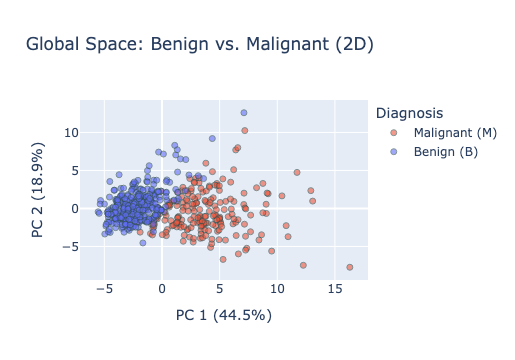

In [9]:
# VISUALIZE: Global Space 2D
fig_global = px.scatter(
    df_global_pca, x='pca1', y='pca2', color='Diagnosis',
    color_discrete_map={'Malignant (M)': '#ef553b', 'Benign (B)': '#636efa'},
    title='Global Space: Benign vs. Malignant (2D)',
    labels={'pca1': f'PC 1 ({var_global[0]*100:.1f}%)', 'pca2': f'PC 2 ({var_global[1]*100:.1f}%)'},
    opacity=0.6
)
fig_global.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))
fig_global.show()

In [10]:
# ==========================================
# PIPELINE 2: GMM MALIGNANT SUB-TYPES & OUTLIER DETECTION
# ==========================================
print("Training GMM Malignant Sub-types Pipeline...")

df_m = df[df['diagnosis'] == 'M'].copy()
X_m = df_m.drop(columns=['diagnosis'])

scaler_malig = StandardScaler()
X_m_scaled = scaler_malig.fit_transform(X_m)

# 2 Components PCA
pca_malig = PCA(n_components=2)
pca_m = pca_malig.fit_transform(X_m_scaled)

var_malig = pca_malig.explained_variance_ratio_
print(f"Malignant PCA Variance Explained: {sum(var_malig)*100:.1f}%")

# Train the Gaussian Mixture Model 
gmm_malig = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_malig.fit(pca_m)

# Predict the primary cluster for the background plot
clusters_m = gmm_malig.predict(pca_m)

# Calculate the Outlier Threshold
# We score all historical malignant tumors. We take the 1st percentile score as our boundary.
# Any future patient who scores lower than this is officially an "Outlier" to the Malignant profile.
m_log_probs = gmm_malig.score_samples(pca_m)
outlier_threshold = np.percentile(m_log_probs, 10)

df_malig_pca = pd.DataFrame({
    'pca1': pca_m[:, 0], 'pca2': pca_m[:, 1],
    'Cluster': [f"Sub-type {c+1}" for c in clusters_m]
})

Training GMM Malignant Sub-types Pipeline...
Malignant PCA Variance Explained: 60.5%


In [11]:
# Save the models, background data, and Outlier Threshold
joblib.dump(scaler_malig, '../models/scaler_malig.joblib')
joblib.dump(pca_malig, '../models/pca_malig.joblib')
joblib.dump(gmm_malig, '../models/gmm_malig.joblib')
joblib.dump(outlier_threshold, '../models/outlier_threshold.joblib')
df_malig_pca.to_csv('../data/malig_pca_background.csv', index=False)

print(f"GMM trained successfully! Malignant Outlier Boundary set at log-likelihood: {outlier_threshold:.2f}")

GMM trained successfully! Malignant Outlier Boundary set at log-likelihood: -6.31


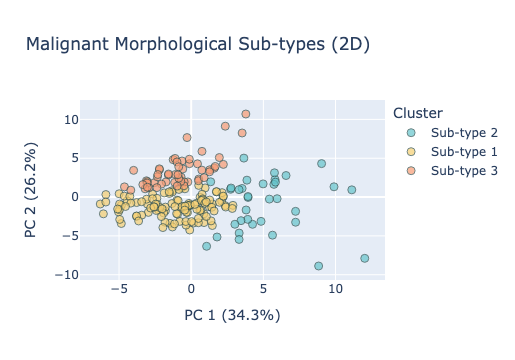

In [12]:
# VISUALIZE: Malignant Sub-types
fig_malig = px.scatter(
    df_malig_pca, x='pca1', y='pca2', color='Cluster',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Malignant Morphological Sub-types (2D)',
    labels={'pca1': f'PC 1 ({var_malig[0]*100:.1f}%)', 'pca2': f'PC 2 ({var_malig[1]*100:.1f}%)'},
    opacity=0.7
)
fig_malig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')))
fig_malig.show()

In [13]:
print("Training models and background datasets saved successfully!")

Training models and background datasets saved successfully!


## GMM Threshold Tuning

In [14]:
# 1. Load the training data and models
df = pd.read_csv('../data/train_data.csv').drop(columns=['id', 'Unnamed: 32'], errors='ignore')
X_all = df.drop(columns=['diagnosis'])

# Create a binary ground truth: 1 for Malignant, 0 for Benign
y_true = (df['diagnosis'] == 'M').astype(int) 

scaler_malig = joblib.load('../models/scaler_malig.joblib')
pca_malig = joblib.load('../models/pca_malig.joblib')
gmm_malig = joblib.load('../models/gmm_malig.joblib')

# 2. Pass ALL patients through the Malignant pipeline
X_scaled = scaler_malig.transform(X_all)
X_pca = pca_malig.transform(X_scaled)

# Get the log-likelihood scores for everyone
log_probs = gmm_malig.score_samples(X_pca)

# Isolate the scores of the TRUE Malignant cases to calculate our percentiles
malig_log_probs = log_probs[y_true == 1]

# 3. Test a sweep of different threshold percentiles
percentiles_to_test = [1, 5, 10, 15, 20, 25]

print("=== GMM Anomaly Detection Tuning ===")
print("Goal: Balance catching Malignant cases vs. correctly identifying Benign outliers.\n")

for p in percentiles_to_test:
    # Calculate the threshold score at this percentile
    threshold = np.percentile(malig_log_probs, p)
    
    # Predict 1 (Malignant) if score is above threshold, else 0 (Benign Outlier)
    y_pred = (log_probs >= threshold).astype(int)
    
    # Calculate metrics
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    fn = cm[1][0] # Malignant cases incorrectly called Outliers (Missed Cancer)
    fp = cm[0][1] # Benign cases incorrectly called Malignant (False Alarm)
    
    print(f"Threshold: {p}th Percentile (Log-Prob cutoff: {threshold:.2f})")
    print(f"  Recall (Malignant caught): {recall*100:.1f}% | Precision: {precision*100:.1f}%")
    print(f"  False Negatives (Missed Cancer): {fn} | False Positives (False Alarms): {fp}")
    print("-" * 60)

=== GMM Anomaly Detection Tuning ===
Goal: Balance catching Malignant cases vs. correctly identifying Benign outliers.

Threshold: 1th Percentile (Log-Prob cutoff: -9.30)
  Recall (Malignant caught): 98.6% | Precision: 37.9%
  False Negatives (Missed Cancer): 3 | False Positives (False Alarms): 334
------------------------------------------------------------
Threshold: 5th Percentile (Log-Prob cutoff: -6.82)
  Recall (Malignant caught): 94.7% | Precision: 53.6%
  False Negatives (Missed Cancer): 11 | False Positives (False Alarms): 170
------------------------------------------------------------
Threshold: 10th Percentile (Log-Prob cutoff: -6.31)
  Recall (Malignant caught): 89.9% | Precision: 58.3%
  False Negatives (Missed Cancer): 21 | False Positives (False Alarms): 133
------------------------------------------------------------
Threshold: 15th Percentile (Log-Prob cutoff: -5.91)
  Recall (Malignant caught): 85.0% | Precision: 64.2%
  False Negatives (Missed Cancer): 31 | False Po

## Feature Importance

## Edge case

In [15]:
# Load data and models
df = pd.read_csv('../data/train_data.csv').drop(columns=['id', 'Unnamed: 32'], errors='ignore')
X_all = df.drop(columns=['diagnosis'])
y_true = (df['diagnosis'] == 'M').astype(int) 

xgb_model = joblib.load('../models/xgb_cancer_model.joblib')
scaler_malig = joblib.load('../models/scaler_malig.joblib')
pca_malig = joblib.load('../models/pca_malig.joblib')
gmm_malig = joblib.load('../models/gmm_malig.joblib')
outlier_threshold = joblib.load('../models/outlier_threshold.joblib') # Assuming this is set to 10th percentile

# 1. XGBoost Predictions (using your 35% safety threshold)
xgb_probs = xgb_model.predict_proba(X_all)[:, 1]
xgb_missed = (xgb_probs < 0.35) & (y_true == 1)

# 2. GMM Predictions (using the 10th percentile threshold)
X_scaled = scaler_malig.transform(X_all)
X_pca = pca_malig.transform(X_scaled)
log_probs = gmm_malig.score_samples(X_pca)
gmm_missed = (log_probs < outlier_threshold) & (y_true == 1)

# 3. Find the exact patients that fooled BOTH
double_misses = df[xgb_missed & gmm_missed].copy()

print(f"Number of patients that fooled both models: {len(double_misses)}")
print("\nFeature profile of the 'Invisible' cancers:")
# Let's look at their top features compared to the average Malignant and Benign tumors
print(double_misses[['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean']])

Number of patients that fooled both models: 0

Feature profile of the 'Invisible' cancers:
Empty DataFrame
Columns: [radius_mean, texture_mean, smoothness_mean, concavity_mean]
Index: []


# Findings
Since the GMM was trained only on the Malignant cases, we are treating it as an Anomaly Detector. The logic is: "If a patient's tumor looks too different from our known Malignant cases (an anomaly/outlier), we classify it as Benign."